In [41]:
# =========================
# 0. SETUP
# =========================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve
)

from pygam import LogisticGAM, s, l

warnings.filterwarnings("ignore")

DATA_FILE = "../../data/processed/cardio_onc_prostate_04cleaned.csv"
TARGET = "at_risk"
SEED = 42
OUT_DIR = "Results/GAM"

os.makedirs(OUT_DIR, exist_ok=True)

COL_FULL = "#378ADD"
COL_REDUCED = "#E24B4A"
COL_REF = "#999999"

In [42]:
# =========================
# 1. DATA
# =========================
df = pd.read_csv(DATA_FILE)
df = df[df[TARGET].notna()].copy()

continuous_features = [
    "bmi", "age", "sbp", "dbp", "ascvd_10yr",
    "days_auth_to_start", "days_adt_to_nht",
]

binary_features = [
    "hx_smoking", "family_hx_hd", "hx_htn",
    "bb_prior", "has_pcp", "hx_hld", "hx_high_tg",
    "other_lipid_prior", "lipid_panel_checked",
    "hx_cad", "hx_mi_stent", "hx_chf", "hx_arrhythmia",
    "hx_carotid", "hx_pad", "hx_cva",
    "a1c_checked", "glucose_over_200",
    "asa_use", "cards_prior", "cards_post", "cards_referral",
    "echo_ordered", "ecg_done", "non_onc_provider",
]

encoded_features = [
    "ethnicity_enc", "specific_nht_used_enc",
    "adt_agent_enc", "prescribing_provider_enc",
]

all_features = continuous_features + binary_features + encoded_features

X_df = df[all_features].astype(float)
y = df[TARGET].astype(int)

X = SimpleImputer(strategy="median").fit_transform(X_df)
feature_names = X_df.columns.tolist()

In [43]:
def split_data(X, y):
    return train_test_split(
        X, y, test_size=0.2,
        stratify=y, random_state=SEED
    )

In [44]:
def compute_metrics(y_true, proba):
    pred = (proba >= 0.5).astype(int)
    return {
        "roc_auc": roc_auc_score(y_true, proba),
        "pr_auc": average_precision_score(y_true, proba),
        "f1": f1_score(y_true, pred),
        "accuracy": accuracy_score(y_true, pred),
        "recall": recall_score(y_true, pred),
        "precision": precision_score(y_true, pred)
    }

In [45]:
def build_gam(X, n_cont, lam=0.6):
    terms = s(0)
    for i in range(1, n_cont):
        terms += s(i)
    for i in range(n_cont, X.shape[1]):
        terms += l(i)

    return LogisticGAM(terms, lam=lam)

In [46]:
def partial_r2_feature_importance(X, y, n_cont, lam=0.6):
    full_model = build_gam(X, n_cont, lam).fit(X, y)
    full_ll = full_model.loglikelihood(X, y)

    results = []

    for j in range(X.shape[1]):
        mask = [i for i in range(X.shape[1]) if i != j]
        X_red = X[:, mask]

        idx_map = {old: new for new, old in enumerate(mask)}

        terms = None

        # continuous
        first = next((i for i in range(n_cont) if i in mask), None)

        if first is not None:
            terms = s(idx_map[first])
            for i in range(n_cont):
                if i in mask and i != first:
                    terms += s(idx_map[i])

            for i in range(n_cont, X.shape[1]):
                if i in mask:
                    terms += l(idx_map[i])
        else:
            terms = l(idx_map[n_cont])
            for i in range(n_cont + 1, X.shape[1]):
                if i in mask:
                    terms += l(idx_map[i])

        model = LogisticGAM(terms, lam=lam).fit(X_red, y)
        ll = model.loglikelihood(X_red, y)

        r2 = 1 - (full_ll / ll)
        results.append(r2)

    return np.array(results)

In [47]:
X_train, X_test, y_train, y_test = split_data(X, y)

n_cont = len(continuous_features)

full_gam = build_gam(X_train, n_cont).fit(X_train, y_train)

proba_full = full_gam.predict_proba(X_test)
metrics_full = compute_metrics(y_test, proba_full)

did not converge


In [48]:
partial_r2 = partial_r2_feature_importance(X_train, y_train, n_cont)

partial_r2_df = pd.DataFrame({
    "feature": feature_names,
    "partial_r2": partial_r2
}).sort_values("partial_r2", ascending=False)

useful_features = partial_r2_df.query("partial_r2 > 0")["feature"].tolist()

did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge
did not converge


In [49]:
X_red = SimpleImputer(strategy="median").fit_transform(df[useful_features].astype(float))

Xr_train, Xr_test, yr_train, yr_test = split_data(X_red, y)

n_cont_red = sum(f in continuous_features for f in useful_features)

reduced_gam = build_gam(Xr_train, n_cont_red).fit(Xr_train, yr_train)

proba_red = reduced_gam.predict_proba(Xr_test)
metrics_red = compute_metrics(yr_test, proba_red)

did not converge


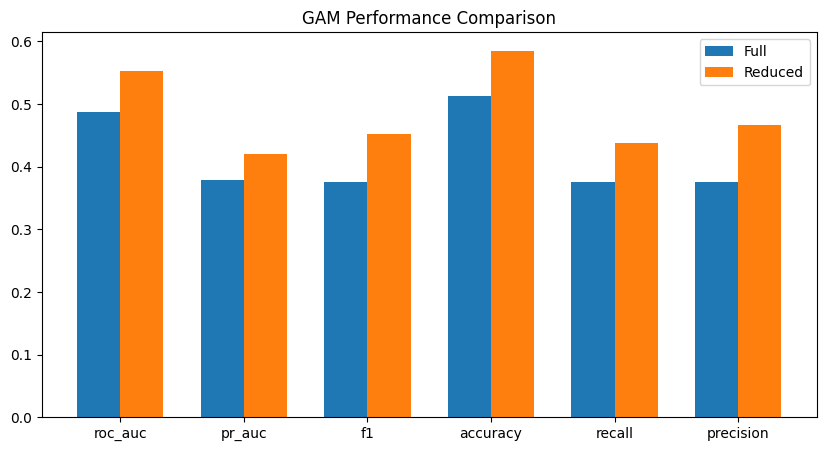

In [52]:
def plot_metrics(metrics_full, metrics_red):
    keys = ["roc_auc","pr_auc","f1","accuracy","recall","precision"]

    x = np.arange(len(keys))
    w = 0.35

    plt.figure(figsize=(10,5))

    plt.bar(x - w/2, [metrics_full[k] for k in keys], w, label="Full")
    plt.bar(x + w/2, [metrics_red[k] for k in keys], w, label="Reduced")

    plt.xticks(x, keys)
    plt.legend()
    plt.title("GAM Performance Comparison")
    plt.show()

plot_metrics(metrics_full, metrics_red)

In [53]:
def plot_roc(y_true_f, p_f, y_true_r, p_r):
    fpr_f, tpr_f, _ = roc_curve(y_true_f, p_f)
    fpr_r, tpr_r, _ = roc_curve(y_true_r, p_r)

    plt.figure(figsize=(6,6))
    plt.plot(fpr_f, tpr_f, label="Full")
    plt.plot(fpr_r, tpr_r, label="Reduced")
    plt.plot([0,1],[0,1],"--")
    plt.legend()
    plt.title("ROC Curve")
    plt.show()

NameError: name 'y_true_f' is not defined